<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day3_exerciseXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Flower Classification using CNN

## Part 1: Data Exploration and Visualization

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib

# Download and extract the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_path)
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

# Global variables
HEIGHT = 48
WIDTH = 48
BATCH_SIZE = 32

# Datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='training', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='validation', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f'Detected classes: {class_names}')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Detected classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Visualizing the images
I will now create a function to display a 3x3 grid for the classes to inspect the data quality and challenges.

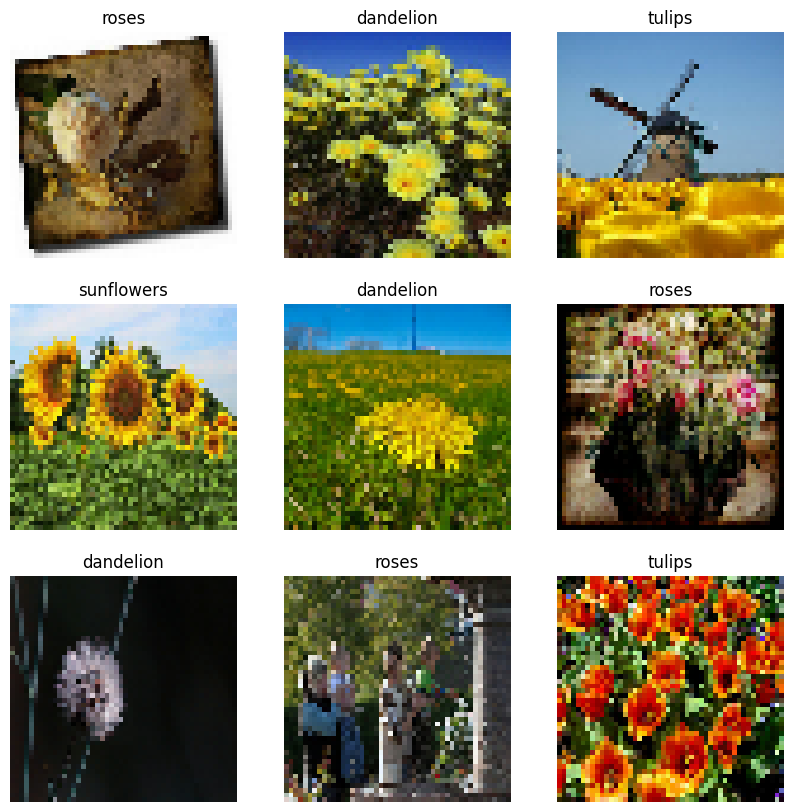

In [5]:
def visualize_images(dataset, class_names):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[labels[i]])
            plt.axis('off')
    plt.show()

if 'train_ds' in locals():
    visualize_images(train_ds, class_names)
else:
    print('Dataset not found in local memory.')

## Part 2: CNN Architecture Design

We will now define the model architecture. This includes:
1. **Rescaling Layer**: Normalizes pixel values from [0, 255] to [0, 1].
2. **Convolutional Layers**: Three blocks of `Conv2D` and `MaxPooling2D` to extract hierarchical features.
3. **Flatten & Dense Layers**: Converts 2D features into a 1D vector for classification.
4. **Dropout**: A layer to reduce overfitting by randomly setting input units to 0 during training.

In [6]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(HEIGHT, WIDTH, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Part 3 & 4: Data Augmentation and Model Training

To prevent overfitting, we'll apply data augmentation. We'll also use an early stopping callback to stop training when the validation loss stops improving.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pathlib

# Ensure data directory and datasets are defined in this scope
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_path)
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

HEIGHT = 48
WIDTH = 48
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='training', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='validation', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(HEIGHT, WIDTH, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Model Definition
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.4441 - loss: 1.2859 - val_accuracy: 0.5095 - val_loss: 1.1504
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.5576 - loss: 1.0935 - val_accuracy: 0.5463 - val_loss: 1.1059
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6069 - loss: 1.0225 - val_accuracy: 0.5504 - val_loss: 1.1281
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6362 - loss: 0.9302 - val_accuracy: 0.5640 - val_loss: 1.0558
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6587 - loss: 0.8748 - val_accuracy: 0.6226 - val_loss: 0.9394
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6638 - loss: 0.8478 - val_accuracy: 0.6403 - val_loss: 0.9329
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 

## Part 5: Performance Evaluation

We will now evaluate the model by:
1. Plotting Training vs Validation Accuracy and Loss.
2. Creating a Confusion Matrix to see class-wise performance.

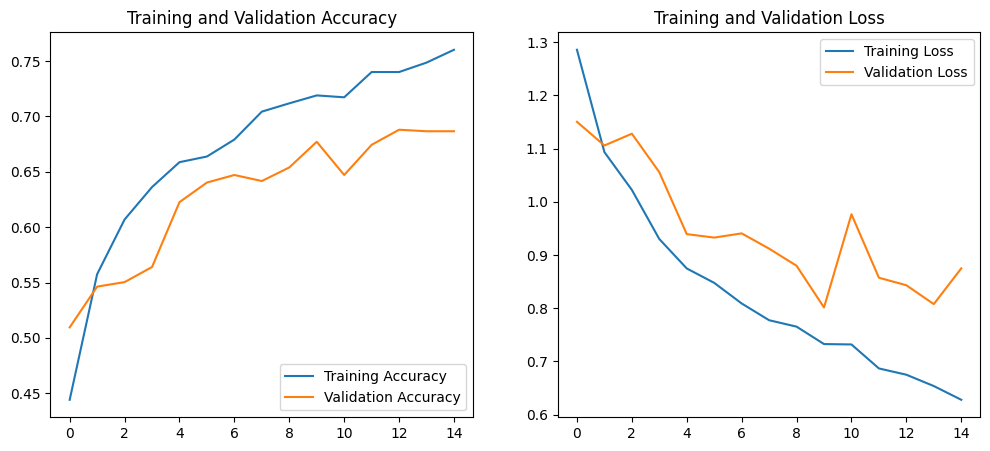

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

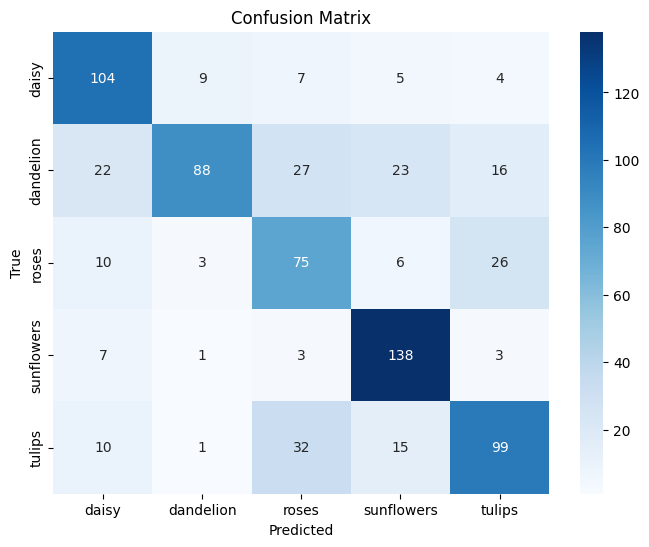

              precision    recall  f1-score   support

       daisy       0.68      0.81      0.74       129
   dandelion       0.86      0.50      0.63       176
       roses       0.52      0.62      0.57       120
  sunflowers       0.74      0.91      0.81       152
      tulips       0.67      0.63      0.65       157

    accuracy                           0.69       734
   macro avg       0.69      0.69      0.68       734
weighted avg       0.71      0.69      0.68       734



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get all predictions and labels for the validation set
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Part 6: Model Deployment (Optional)

Saving the model allows you to reuse it later without having to repeat the training process. We will save it in the HDF5 format (`.h5`).

In [21]:
import os

# On vérifie quel modèle est disponible en mémoire pour le sauvegarder
model_to_save = None
model_name = ""

if 'pretrained_model' in locals():
    model_to_save = pretrained_model
    model_name = "pretrained_flower_model.h5"
elif 'small_model' in locals():
    model_to_save = small_model
    model_name = "small_flower_model.h5"
elif 'model' in locals():
    model_to_save = model
    model_name = "flower_classification_model.h5"

if model_to_save is not None:
    model_to_save.save(model_name)
    print(f'Succès ! Le modèle a été sauvegardé sous le nom : {model_name}')

    # Optionnel : Code pour télécharger automatiquement
    # from google.colab import files
    # files.download(model_name)
else:
    print('Erreur : Aucun modèle (model, small_model ou pretrained_model) n\'a été trouvé en mémoire. Veuillez ré-exécuter une cellule d\'entraînement.')

Succès ! Le modèle a été sauvegardé sous le nom : pretrained_flower_model.h5


## Exercise XP GOLD: Image Classification with Limited Data

In this section, we focus on techniques to prevent overfitting when working with smaller datasets:
1. **Data Augmentation** (Already implemented in Part 3).
2. **Dropout**.
3. **Smaller Model Architecture**.
4. **Early Stopping**.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pathlib

# Re-verifying data and variables since runtime was reset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_path)
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

HEIGHT, WIDTH, BATCH_SIZE = 48, 48, 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='training', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='validation', seed=123, image_size=(HEIGHT, WIDTH), batch_size=BATCH_SIZE
)

num_classes = 5
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(HEIGHT, WIDTH, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# Define a callback for Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Create a smaller model architecture for Exercise 2
small_model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes)
])

small_model.compile(optimizer='adam',
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=['accuracy'])

print("Training the smaller model with Early Stopping...")
small_history = small_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Training the smaller model with Early Stopping...
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.4363 - loss: 1.3171 - val_accuracy: 0.4973 - val_loss: 1.1846
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5399 - loss: 1.1124 - val_accuracy: 0.5504 - val_loss: 1.1096
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5760 - loss: 1.0545 - val_accuracy: 0.5926 - val_loss: 1.0113
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6056 - loss: 1.0074 - val_accuracy: 0.5940 - val_loss: 0.9987
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6270 - loss: 0.9594 - val_accuracy: 0.6090 - val_loss: 1.0231
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6413 - loss: 0.9169 - val_accuracy: 0.6240 - val_lo

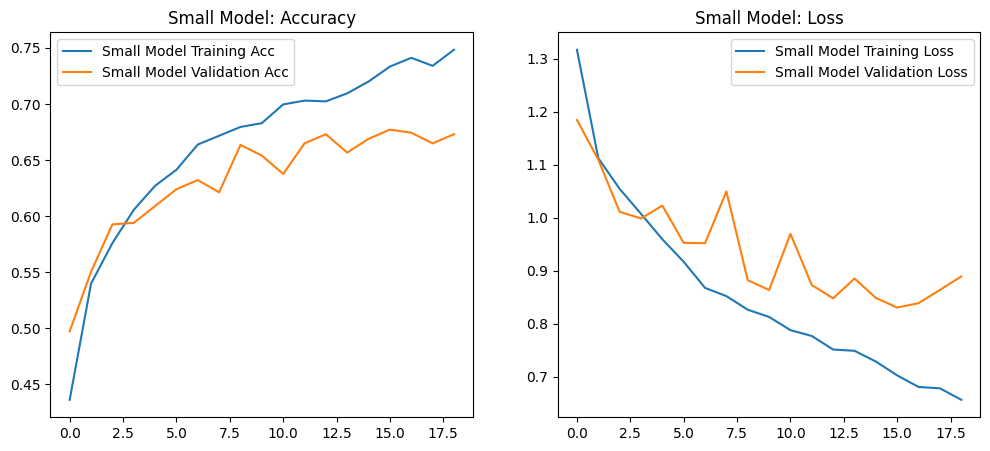

In [7]:
import matplotlib.pyplot as plt

s_acc = small_history.history['accuracy']
s_val_acc = small_history.history['val_accuracy']
s_loss = small_history.history['loss']
s_val_loss = small_history.history['val_loss']
s_epochs_range = range(len(s_acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(s_epochs_range, s_acc, label='Small Model Training Acc')
plt.plot(s_epochs_range, s_val_acc, label='Small Model Validation Acc')
plt.title('Small Model: Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(s_epochs_range, s_loss, label='Small Model Training Loss')
plt.plot(s_epochs_range, s_val_loss, label='Small Model Validation Loss')
plt.title('Small Model: Loss')
plt.legend()
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Create the base model from the pre-trained MobileNetV2
# We exclude the top classification layer
base_model = tf.keras.applications.MobileNetV2(input_shape=(HEIGHT, WIDTH, 3),
                                               include_top=False,
                                               weights='imagenet')

# 2. Freeze the base model so we don't update its weights
base_model.trainable = False

# 3. Build the model architecture
pretrained_model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(HEIGHT, WIDTH, 3)), # MobileNetV2 expects [-1, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes)
])

pretrained_model.compile(optimizer='adam',
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                         metrics=['accuracy'])

print("Training the pre-trained feature extractor...")
pre_history = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

/tmp/ipykernel_1444/2502766988.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(HEIGHT, WIDTH, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training the pre-trained feature extractor...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 315ms/step - accuracy: 0.5048 - loss: 1.3747 - val_accuracy: 0.6512 - val_loss: 0.9653
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6444 - loss: 0.9571 - val_accuracy: 0.6730 - val_loss: 0.8792
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6918 - loss: 0.8138 - val_accuracy: 0.6866 - val_loss: 0.8480
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7272 - loss: 0.7331 - val_accuracy: 0.6866 - val_loss: 0.8519
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7476 - loss: 0.6726 - val_accuracy: 0.6826 - val_loss: 0.8434
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7704 - loss: 0.6188 - val_accuracy: 0.6839 - val_loss: 0.8457
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7776 - loss: 0.5962 - val_accuracy: 0.6989 - val_loss: 0.8349
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8001 - loss: 0.5425 - val_accuracy: 0.6935 - val_loss: 

### Exercise 3: Performance Analysis
We visualize the pre-trained model's results and compare them to our scratch-built models.

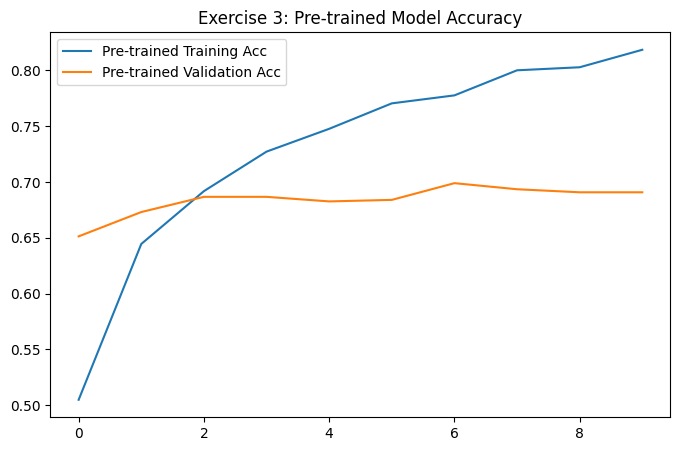

In [9]:
acc = pre_history.history['accuracy']
val_acc = pre_history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Pre-trained Training Acc')
plt.plot(epochs_range, val_acc, label='Pre-trained Validation Acc')
plt.title('Exercise 3: Pre-trained Model Accuracy')
plt.legend()
plt.show()

### Exercise XP NINJA: Fine-tuning the Pre-trained Model
Now we will unfreeze the top layers of the MobileNetV2 base model to fine-tune the weights for better accuracy.

In [12]:
if 'base_model' in locals():
    # Unfreeze the base model
    base_model.trainable = True

    # Let's see how many layers are in the base model
    print(f'Number of layers in the base model: {len(base_model.layers)}')

    # Fine-tune from this layer onwards
    fine_tune_at = 100

    # Freeze all the layers before the `fine_tune_at` layer
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Recompile with a lower learning rate
    pretrained_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                             metrics=['accuracy'])

    print('Fine-tuning the model...')
    fine_tune_epochs = 10
    total_epochs = 10 + fine_tune_epochs

    history_fine = pretrained_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=total_epochs,
        initial_epoch=pre_history.epoch[-1]
    )
else:
    print('Error: base_model or pretrained_model not found.')

Number of layers in the base model: 154
Fine-tuning the model...
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 238ms/step - accuracy: 0.5181 - loss: 1.4159 - val_accuracy: 0.6267 - val_loss: 1.3819
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6717 - loss: 0.8998 - val_accuracy: 0.6662 - val_loss: 1.3908
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7340 - loss: 0.7468 - val_accuracy: 0.6798 - val_loss: 1.2135
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7854 - loss: 0.5796 - val_accuracy: 0.7030 - val_loss: 1.1907
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8093 - loss: 0.5185 - val_accuracy: 0.7044 - val_loss: 1.2403
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8576 - loss: 0.4028 - val_accuracy: 0.7221 - val_loss: 1.1479
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8641 - loss: 0.3665 - val_accuracy: 0.7371 - val_loss: 1.1459
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━

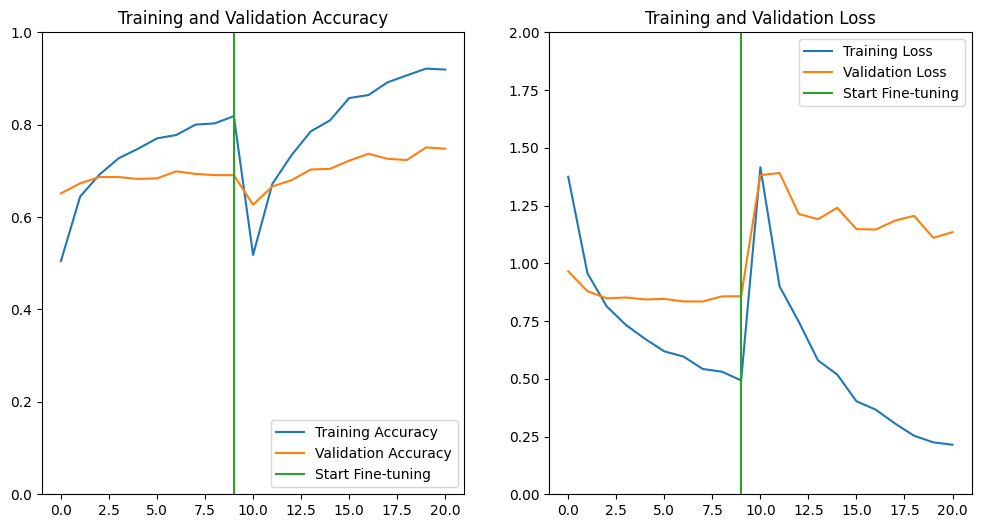

In [13]:
if 'history_fine' in locals():
    acc = pre_history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = pre_history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = pre_history.history['loss'] + history_fine.history['loss']
    val_loss = pre_history.history['val_loss'] + history_fine.history['val_loss']

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.ylim([0, 1])
    plt.plot([10-1, 10-1], plt.ylim(), label='Start Fine-tuning')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.ylim([0, 2.0])
    plt.plot([10-1, 10-1], plt.ylim(), label='Start Fine-tuning')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()
else:
    print('Fine-tuning history not found.')

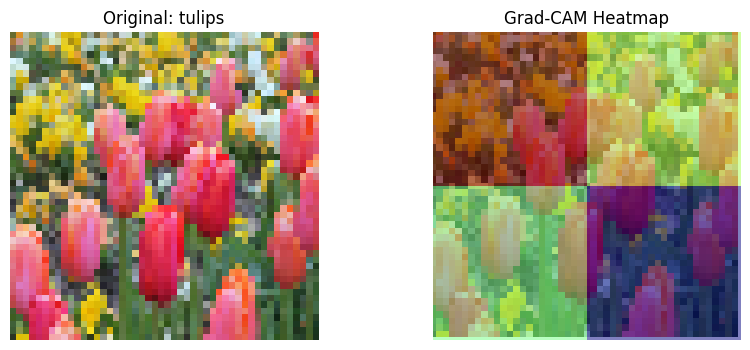

In [18]:
import numpy as np
import matplotlib.cm as cm
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure class_names is available
if 'train_ds' in locals():
    class_names = train_ds.class_names
else:
    # Fallback if dataset is not in memory
    class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Access the base model (MobileNetV2)
    base_layer = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_layer.get_layer(last_conv_layer_name)

    # Sub-model for gradients
    base_model_grad = tf.keras.Model([base_layer.input], [last_conv_layer.output, base_layer.output])

    # 3. Preprocessing
    rescaling_layer = model.get_layer('rescaling_1')
    rescaled_img = rescaling_layer(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = base_model_grad(rescaled_img)
        x = model.get_layer('global_average_pooling2d')(base_outputs)
        x = model.get_layer('dropout_1')(x)
        preds = model.get_layer('dense_2')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Select a sample
if 'val_ds' in locals():
    for images, labels in val_ds.take(1):
        img_sample = images[0:1]
        label_sample = labels[0]

    # Run Grad-CAM
    last_conv_layer_name = "Conv_1"
    heatmap = make_gradcam_heatmap(img_sample, pretrained_model, last_conv_layer_name)

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_sample[0].numpy().astype('uint8'))
    plt.title(f"Original: {class_names[label_sample]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_sample[0].numpy().astype('uint8'))
    plt.imshow(heatmap, cmap='jet', alpha=0.5, extent=(0, 48, 48, 0)) # Resized overlay
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()
else:
    print('Error: val_ds not found. Please run the data loading cells first.')

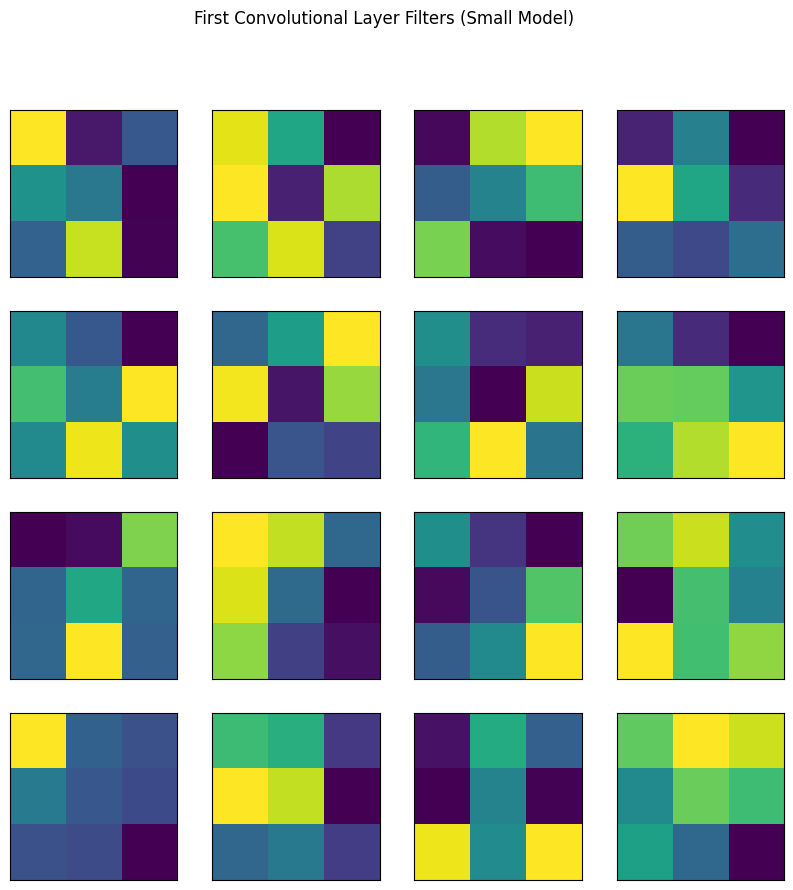

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Exercise 4: Visualizing filters from the 'small_model' trained in Exercise 2
if 'small_model' in locals():
    # In small_model: layer 0 is augmentation, 1 is rescaling, 2 is Conv2D
    layer = small_model.layers[2]
    filters, biases = layer.get_weights()

    # Normalize filter values to 0-1 for visualization
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)

    # Plot the first 16 filters
    n_filters, ix = 16, 1
    plt.figure(figsize=(10, 10))
    for i in range(n_filters):
        # Get the filter
        f = filters[:, :, :, i]
        # Plot each channel (0=Red, 1=Green, 2=Blue) - here we just show the first channel
        ax = plt.subplot(4, 4, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(f[:, :, 0], cmap='viridis')
        ix += 1
    plt.suptitle('First Convolutional Layer Filters (Small Model)')
    plt.show()
else:
    print('Error: small_model not found. Please run the Exercise 2 training cell first.')